# Modelagem: Curva de Demanda e Otimização de Preços

Consome a curva de demanda oficial decidida em `01-EDA_v3.ipynb` (seção "Decisão Final de Tratamento"), reproduzida aqui via `src/modeling/demand_curve.py` — não reajusta nada do zero, para não divergir da decisão já tomada e validada no EDA.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
if not os.path.isdir('data'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

print(f"Diretório de trabalho atualizado para: {os.getcwd()}")


Diretório de trabalho atualizado para: /Users/ngodeny/Documents/mestrado/2026-resolucao_problemas/2026_resolucao_problemas


## Carregando os dados tratados no EDA

In [3]:
caminho_dados = 'data/processed/treino_tratado_clusters.csv'
df_treino = pd.read_csv(caminho_dados, parse_dates=['Data'])

print(f"Dados carregados com sucesso! Tamanho: {df_treino.shape}")
df_treino[['Data', 'Dia da Semana', 'Preço', 'Volume Realizado (kg)', 'Cluster']].head()


Dados carregados com sucesso! Tamanho: (76, 12)


,Data,Dia da Semana,Preço,Volume Realizado (kg),Cluster
0,2025-08-01,Sexta,1267.949227,5.625635,Fraco
1,2025-08-04,Segunda,1279.335771,31.390461,Pico
2,2025-08-05,Terça,1258.408986,22.184888,TerQuaQui
3,2025-08-06,Quarta,1241.133798,11.030794,TerQuaQui
4,2025-08-07,Quinta,1253.118993,15.160805,TerQuaQui


## Curva de demanda (reproduzida de `src/modeling/demand_curve.py`)

A curva oficial: 4 grupos (Pico/TerQuaQui/Fraco/FimDeSemana), elasticidade única, ajustada por regressão robusta de Huber sobre Volume bruto — decisão justificada no EDA (Torneio de Modelos + Torneio 2: Tratamento de Outlier x Agrupamento). Nada é reajustado aqui manualmente: `fit_demand_curve` é a mesma função usada (e validada) no notebook 01.

In [4]:
from src.modeling.demand_curve import fit_demand_curve, predict_volume, assign_cluster

modelo_demanda = fit_demand_curve(df_treino)

print("=== Coeficientes da curva de demanda oficial ===")
print(modelo_demanda.params.round(3))
print()
print(modelo_demanda.pvalues.round(4))


2026-09-02 16:46:57.417 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/ngodeny/Documents/mestrado/2026-resolucao_problemas/2026_resolucao_problemas


=== Coeficientes da curva de demanda oficial ===
const          103.955
ln_Preco       -14.099
FimDeSemana     -2.759
Fraco           -1.288
Pico             0.296
dtype: float64

const          0.0000
ln_Preco       0.0000
FimDeSemana    0.0000
Fraco          0.0000
Pico           0.0373
dtype: float64


## Simulação da curva por grupo

Visualização de `Volume = A · Preço⁻ᴮ` para cada grupo, dentro da faixa de preço observada no treino (fora dela é extrapolação — ver seção "Melhoria 4" do EDA).

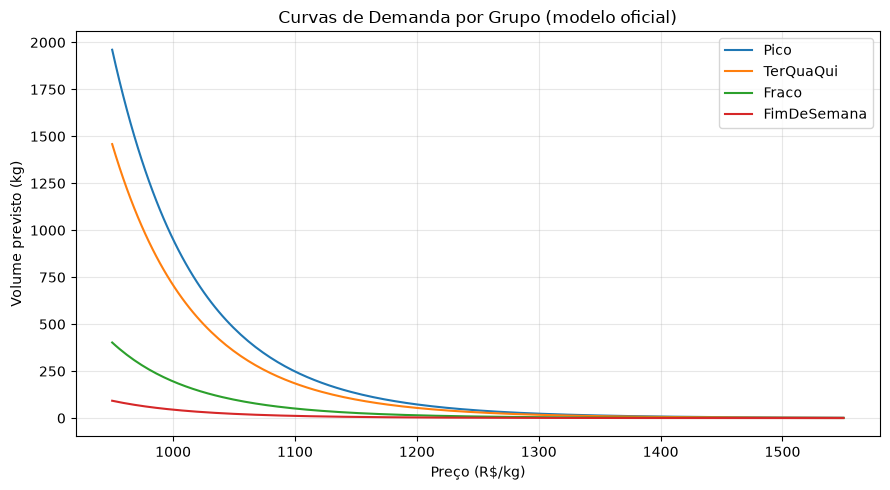

In [5]:
precos_simulados = np.linspace(950, 1550, 200)
grupos = ['Pico', 'TerQuaQui', 'Fraco', 'FimDeSemana']

plt.figure(figsize=(9, 5))
for grupo in grupos:
    volumes = [predict_volume(modelo_demanda, p, grupo) for p in precos_simulados]
    plt.plot(precos_simulados, volumes, label=grupo)

plt.title('Curvas de Demanda por Grupo (modelo oficial)')
plt.xlabel('Preço (R$/kg)')
plt.ylabel('Volume previsto (kg)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Próximos passos: Otimização

Com a curva de demanda definida e validada, o passo seguinte é a Programação Matemática pedida no desafio (seção 0.5 do PDF): definir a sequência de preços diários que maximiza a margem acumulada, sujeita a (1) meta semanal de volume (165 kg ± 30%) e (2) variação máxima de preço entre dias consecutivos (R$ 2,00). Ainda não implementado neste notebook.